In [34]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

In [35]:
seed = 42

root_path = "/home/stefan/ioai-prep/kits/algolymp/sad-squid/"

In [55]:
df_train_raw = pd.read_csv(root_path + "train_data.csv")
df_train_raw["id"].nunique()

336

In [37]:
row = df_train_raw.iloc[0]

token = "D" + str(row["duration"]) + " P" + str(row["pitch"])
token

'D0.32 P64.0'

# Data

In [38]:
round(0.32 * 4) / 4, round(0.36 * 4) / 4, round(0.872 * 4) / 4

(0.25, 0.25, 0.75)

In [39]:
def create_musical_vocab(df):
    df = df.copy()

    # Calculate semitone intervals
    df["interval"] = df.groupby("id")["pitch"].diff().fillna(0).astype(int)

    # Quantize duration to 4 bins per unit (0.25 precision) to group similar rhythms
    df["quant_dur"] = (df["duration"] * 4).round() / 4

    # 'i' for interval, 'd' for duration
    df["token"] = "i" + df["interval"].astype(str) + "d" + df["quant_dur"].astype(str)

    return df.groupby("id")["token"].apply(lambda x: " ".join(x))


def get_meta_features(df):
    return df.groupby("id").agg(
        {
            "pitch": ["mean", "std", "min", "max"],
            "duration": ["mean", "std", "sum", "count"],
        }
    )

In [40]:
df_train_raw = pd.read_csv(root_path + "train_data.csv")
df_test_raw = pd.read_csv(root_path + "test_data.csv")
df_comp = pd.read_csv(root_path + "composers.csv")

In [59]:
train_docs = create_musical_vocab(df_train_raw)
test_docs = create_musical_vocab(df_test_raw)

train_docs

id
0      i0d0.25 i-24d0.0 i-1d0.0 i1d0.25 i22d0.25 i-2d...
1      i0d0.75 i-27d0.75 i26d0.5 i-2d0.25 i-1d0.5 i1d...
2      i0d4.0 i-12d4.25 i3d4.5 i5d4.5 i-24d4.0 i-5d4....
3      i0d3.0 i7d3.75 i5d1.5 i4d0.25 i3d0.25 i5d0.25 ...
4      i0d0.5 i4d0.25 i1d1.5 i-8d0.75 i-16d0.75 i12d0...
                             ...                        
472    i0d1.25 i-12d0.25 i4d0.0 i-4d0.0 i4d0.0 i-4d0....
473    i0d1.0 i-12d1.0 i19d1.0 i-12d1.0 i11d0.5 i-12d...
476    i0d1.0 i12d0.75 i-9d0.5 i-3d0.75 i12d0.5 i-9d0...
477    i0d7.0 i-12d6.75 i-24d6.75 i-12d6.5 i40d0.5 i1...
479    i0d0.0 i-12d0.0 i4d0.0 i-9d0.0 i-10d0.0 i7d0.0...
Name: token, Length: 336, dtype: object

In [42]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000, sublinear_tf=True)
X_tfidf_train = vectorizer.fit_transform(train_docs).toarray()
X_tfidf_test = vectorizer.transform(test_docs).toarray()

In [53]:
X_tfidf_train.shape

(336, 3000)

In [ ]:
X_meta_train = get_meta_features(df_train_raw).loc[train_docs.index].values
X_meta_test = get_meta_features(df_test_raw).loc[test_docs.index].values

In [45]:
X_train_full = np.hstack([X_tfidf_train, X_meta_train])
X_test_full = np.hstack([X_tfidf_test, X_meta_test])

In [46]:
le = LabelEncoder()
y_all = le.fit_transform(df_comp.set_index("id").loc[train_docs.index]["composer"])

In [58]:
np.unique(y_all, return_counts=True)

(array([0, 1, 2, 3, 4]), array([64, 67, 74, 65, 66]))

# Model

In [47]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_all, test_size=0.1, stratify=y_all, random_state=42
)

In [48]:
model = RandomForestClassifier(
    n_estimators=400,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<Axes: ylabel='Count'>

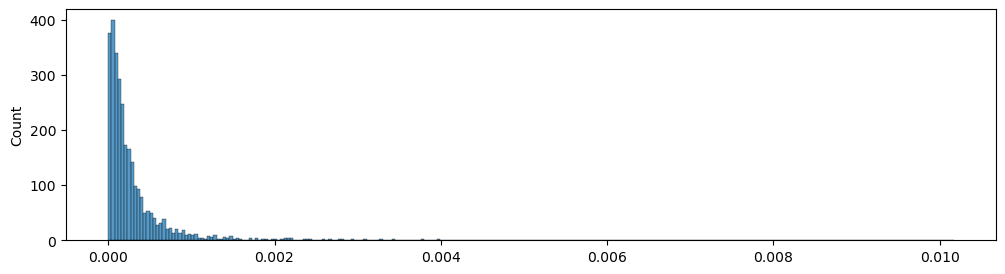

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
sns.histplot(np.sort(model.feature_importances_))

In [49]:
val_preds = model.predict(X_val)
print(f"Validation F1: {f1_score(y_val, val_preds, average='weighted'):.4f}")

Validation F1: 0.9028


# Submission

In [50]:
test_preds = model.predict(X_test_full)
submission = pd.DataFrame(
    {
        "subtaskID": 1,
        "datapointID": test_docs.index,
        "answer": le.inverse_transform(test_preds),
    }
)
submission.to_csv(root_path + "submission1.csv", index=False)